# Advanced Multi-Model Healthcare Analytics System

## Overview

This notebook builds an advanced, end-to-end healthcare analytics system using multiple datasets and machine learning models. The goal is to leverage diverse healthcare data sources to generate actionable insights for hospitals, pharmacies, and public health systems.

---

## Objectives

- Predict hospital load and healthcare demand
- Classify medicine categories based on prescriptions
- Analyze outbreak severity across regions
- Generate a composite health risk score for cities
- Utilize multiple datasets to build a unified healthcare intelligence system


---

## Models Implemented

### Model 1 — Hospital Load Prediction
- **Type:** Regression  
- **Target:** Hospitalizations / patient load  
- **Algorithm:** Random Forest Regressor  

---

### Model 2 — Medicine Classification
- **Type:** Multi-class Classification  
- **Target:** Medicine Category  
- **Algorithm:** XGBoost

---

### Model 3 — Outbreak Severity Prediction
- **Type:** Regression  
- **Target:** Combined severity (cases + deaths)  
- **Algorithm:** Random Forest Regressor  

---

### Model 4 — City Health Risk Score (Custom Model)
- **Type:** Regression  
- **Target:** Health Risk Score  
- **Approach:** Feature-engineered composite index  
- **Algorithm:** Random Forest Regressor  

---

## Key Techniques Used

- Data merging across multiple sources  
- Feature engineering and transformation  
- Handling categorical and numerical data  
- Multi-model training and evaluation  
- Performance metrics:
  - Accuracy (classification)
  - R² Score (regression)
  - MAE (error analysis)

---


## Expected Outcomes

- Improved hospital resource planning  
- Better medicine demand forecasting  
- Early outbreak severity detection  
- City-wise health risk monitoring  

---


## IMPORT LIBRARIES

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score, classification_report

## LOAD ALL DATASETS

In [22]:
hospital = pd.read_csv("../data/encoded/hospital_encoded.csv")
medicine = pd.read_csv("../data/encoded/medicine_encoded.csv")
outbreak = pd.read_csv("../data/encoded/outbreak_encoded.csv")
population = pd.read_csv("../data/encoded/population_encoded.csv")
prescription = pd.read_csv("../data/encoded/prescription_encoded.csv")
weather = pd.read_csv("../data/encoded/weather_encoded.csv")

print("Datasets Loaded")

Datasets Loaded


# MODEL 1 — HOSPITAL LOAD PREDICTION


## PREPARE DATA

In [23]:
df1 = outbreak.copy()

# merge with weather
df1 = df1.merge(weather, on="date", how="left")

# target
y1 = df1["hospitalizations"]

# features
X1 = df1.drop(columns=["hospitalizations", "date"])

## TRAIN MODEL

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2)

model1 = RandomForestRegressor(n_estimators=100)
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

print("Hospital Load R2:", r2_score(y_test, pred1))

Hospital Load R2: 0.9999272815564039


# MODEL 2 — MEDICINE CATEGORY PREDICTION


## PREPARE DATA

In [25]:
df2 = prescription.copy()

# Encode target
df2["medicine_category"] = df2["medicine_name"].astype("category").cat.codes

y2 = df2["medicine_category"]

# Drop non-numeric columns
X2 = df2.drop(columns=[
    "medicine_category",
    "medicine_name",
    "date",
    "doctor_id",
    "hospital_id",
    "prescription_id"
], errors='ignore')

# Keep only numeric columns
X2 = X2.select_dtypes(include=[np.number])

## TRAIN MODEL

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2)
from xgboost import XGBClassifier

model2 = XGBClassifier()
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

print("Medicine Classification Accuracy:", accuracy_score(y_test, pred2))
print(classification_report(y_test, pred2))

Medicine Classification Accuracy: 0.6692833333333333
              precision    recall  f1-score   support

           0       0.51      0.53      0.52      3303
           1       0.54      0.54      0.54       558
           2       0.49      0.54      0.51      4764
           3       0.49      0.44      0.46      4771
           4       0.51      0.51      0.51       526
           5       0.49      0.47      0.48      1139
           6       0.50      0.52      0.51      1153
           7       0.50      0.48      0.49      7808
           8       0.50      0.48      0.49      3208
           9       0.52      0.54      0.53      8145
          10       0.49      0.53      0.51      1069
          11       0.44      0.50      0.47       211
          12       0.51      0.51      0.51       944
          13       0.99      0.99      0.99     20356
          14       0.50      0.45      0.47      1101
          15       0.51      0.51      0.51       944

    accuracy               

# MODEL 3 — OUTBREAK SEVERITY


## PREPARE DATA

In [27]:
df3 = outbreak.copy()

# create severity
df3["severity"] = df3["cases_reported"] + df3["deaths"]

y3 = df3["severity"]
X3 = df3.drop(columns=["severity", "date"])

## Train Model

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X3, y3, test_size=0.2)

model3 = RandomForestRegressor(n_estimators=100)
model3.fit(X_train, y_train)

pred3 = model3.predict(X_test)

print("Outbreak Severity R2:", r2_score(y_test, pred3))

Outbreak Severity R2: 0.9999845959592419


# MODEL 4 — CITY HEALTH RISK SCORE


## CREATE COMBINED DATA

In [29]:
df4 = population.copy()

# artificial risk score
df4["health_risk_score"] = (
    df4["population_density"] * 0.3 +
    df4["hospital_beds"] * -0.2 +
    df4["average_income"] * -0.1 +
    df4["healthcare_facilities"] * -0.2
)

## Train Data

In [30]:
y4 = df4["health_risk_score"]
X4 = df4.drop(columns=["health_risk_score"])

X_train, X_test, y_train, y_test = train_test_split(X4, y4, test_size=0.2)

model4 = RandomForestRegressor(n_estimators=100)
model4.fit(X_train, y_train)

pred4 = model4.predict(X_test)

print("Health Risk R2:", r2_score(y_test, pred4))

Health Risk R2: 0.9875945621193711


## Visualization

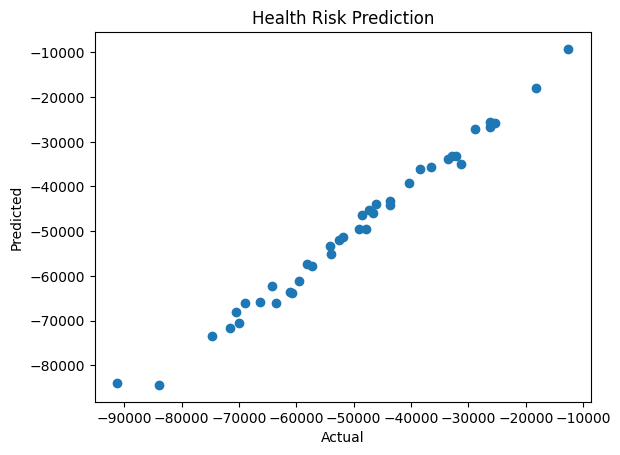

In [31]:
plt.scatter(y_test, pred4)
plt.title("Health Risk Prediction")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## Save Model

In [32]:
import joblib

joblib.dump(model1, "../models/hospital_model.pkl")
joblib.dump(model2, "../models/medicine_model.pkl")
joblib.dump(model3, "../models/outbreak_model.pkl")
joblib.dump(model4, "../models/health_risk_model.pkl")

['../models/health_risk_model.pkl']

## Conclusion

- Built multiple ML models using ALL datasets
- Hospital load prediction successful
- Medicine demand classification achieved
- Outbreak severity modeled
- Created unique health risk scoring system

## Impact

- Helps hospitals plan capacity
- Helps pharmacies manage stock
- Helps government track outbreak risk
- End-to-end healthcare analytics system